# Dropout

Comparativa entre un modelo base que predice calificaciones de peliculas en IMDb y el mismo modelo con *dropout*

Recuperar y preprocesar datos.

In [2]:
from keras.datasets import imdb

(train_data, train_labels), (test_data, test_labels) = imdb.load_data(
num_words=10000)

In [3]:
import numpy as np

"""Vectoriza un un conjunto de conjuntos de datos numericos en codificación ONE-HOT.
Persiste la información del contenido de cada conjunto pero se pierde todo lo relacionado
al orden y la cantidad de veces que aparece cada valor.

Keyword arguments:
sequences -- Conjunto de conjuntos de valores numericos.
dimension -- (def=10000) Cantidad de dimenciones a considerar para el tamaño de cada 
vectorizacion ONE-HOT.
Return: Conjunto de Conjuntos Vectorizado ONE-HOT
"""
def vectorize_sequences(sequences, dimension=10000):
    result = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        result[i, sequence] = 1
    return result
        
x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)

y_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')

x_val = x_train[:10000]
partial_x_train = x_train[10000:]
y_val = y_train[:10000]
partial_y_train = y_train[10000:]

Modelo Base:

In [7]:
from tensorflow.keras import models
from tensorflow.keras import layers
from tensorflow.keras import regularizers

# Tamaños de modelo con los que realizar pruebas

model = models.Sequential()
model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])

base_history = model.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val))

base_val_loss_values = base_history.history['val_loss']
base_val_acc_values = base_history.history['val_acc']

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - acc: 0.6892 - loss: 0.6084 - val_acc: 0.8572 - val_loss: 0.4156
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.8906 - loss: 0.3602 - val_acc: 0.8812 - val_loss: 0.3243
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9117 - loss: 0.2700 - val_acc: 0.8869 - val_loss: 0.2889
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9351 - loss: 0.2069 - val_acc: 0.8866 - val_loss: 0.2802
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9447 - loss: 0.1696 - val_acc: 0.8820 - val_loss: 0.2906
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9564 - loss: 0.1413 - val_acc: 0.8856 - val_loss: 0.2818
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - acc: 0.9643 - loss: 0.1182 - val_acc: 0.8853 - val_loss: 0.2917
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9740 - loss: 0.1003 - val_acc: 0.8830 - val_loss: 0.3090
Epoch 9/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9763

Modelo con Dropout:

In [8]:
from tensorflow.keras import models
from tensorflow.keras import layers
from tensorflow.keras import regularizers

# Tamaños de modelo con los que realizar pruebas

model = models.Sequential()
model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])

history = model.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val))

val_loss_values = history.history['val_loss']
al_acc_values = history.history['val_acc']

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 95ms/step - acc: 0.5539 - loss: 0.6785 - val_acc: 0.8089 - val_loss: 0.5698
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.6940 - loss: 0.5750 - val_acc: 0.8638 - val_loss: 0.4595
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.7884 - loss: 0.4892 - val_acc: 0.8738 - val_loss: 0.3930
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.8350 - loss: 0.4201 - val_acc: 0.8749 - val_loss: 0.3476
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.8711 - loss: 0.3784 - val_acc: 0.8820 - val_loss: 0.3358
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.8946 - loss: 0.3215 - val_acc: 0.8879 - val_loss: 0.3088
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9149 - loss: 0.2899 - val_acc: 0.8874 - val_loss: 0.3082
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9262 - loss: 0.2594 - val_acc: 0.8864 - val_loss: 0.2959
Epoch 9/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9371

Analisis gráfico:

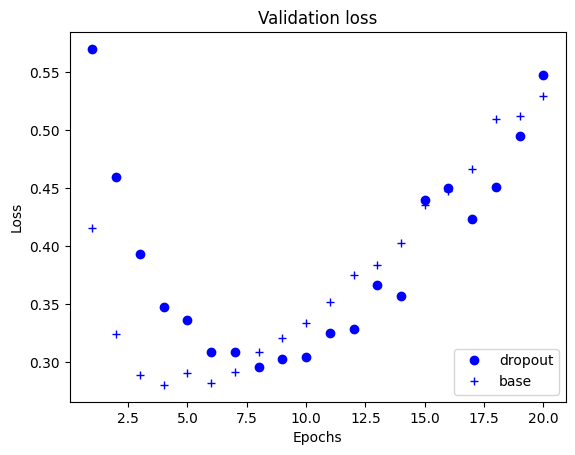

In [10]:
import matplotlib.pyplot as plt

val_loss_values = history.history['val_loss']
epochs = range(1, len(val_loss_values) + 1)

plt.plot(epochs, val_loss_values, 'o', label="dropout", color="blue")
plt.plot(epochs, base_val_loss_values, '+', label="base", color="blue")
plt.title('Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

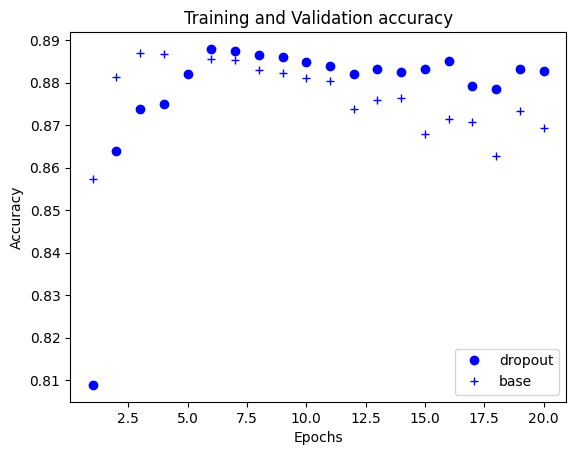

In [11]:
import matplotlib.pyplot as plt

val_acc_values = history.history['val_acc']
epochs = range(1, len(val_acc_values) + 1)

plt.plot(epochs, val_acc_values, 'o', label="dropout", color="blue")
plt.plot(epochs, base_val_acc_values, '+', label="base", color="blue")
plt.title('Training and Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

Hay algo de ruido pero los efectos del *dropout* son claramente beneficiosos se posterga el inicio del *overfitting* y se reduce la velocidad en la que el *overfitting* se manifiesta. Persiste el maximo *acc* alcanzado y en *loss* empeora pero no de forma significativa. No lo sufiente como para que *acc* disminuya.